<a href="https://colab.research.google.com/github/SauSauN/Data_Nelly_Academic_Project/blob/main/Data_viz_tp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1) Prise en main du dataset

### 1. Charger le dataset.

In [64]:
df = sns.load_dataset("titanic")

### 2. Afficher les 10 premières lignes.

In [65]:
df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


### 3. Donner la dimension du dataset.

In [66]:
df.shape

(891, 15)

### 4. Lister l’ensemble des colonnes.

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


### 5. Identifier la nature de chaque variable.

In [68]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### 6. Identifier explicitement la variable cible.

In [69]:
y = df["survived"]
print("Variable cible (y) :")
print(y.head())

Variable cible (y) :
0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64


# Questions

### 1. Quelle est la structure générale du dataset?
### 2. Quelles variables sont numériques?
### 3. Quelles variables sont catégorielles?
### 4. Pourquoi la variable survived peut-elle être considérée comme une cible de classification?

# 2) Vérification de la variable cible et des classes

### 1. Donner le nombre exact de classes.

In [70]:
nombre_classes = df['pclass'].nunique()
print("Nombre exact de classes :", nombre_classes)

Nombre exact de classes : 3


### 2. Donner l’effectif exact de chaque classe.

In [71]:
effectifs_classes = df['pclass'].value_counts().sort_index()
print("\nEffectif de chaque classe :\n", effectifs_classes)


Effectif de chaque classe :
 pclass
1    216
2    184
3    491
Name: count, dtype: int64


### 3. Calculer la proportion de chaque classe.

In [72]:
proportions_classes = df['pclass'].value_counts(normalize=True).sort_index()
print("\nProportion de chaque classe :\n", proportions_classes)


Proportion de chaque classe :
 pclass
1    0.242424
2    0.206510
3    0.551066
Name: proportion, dtype: float64


### 4. Produire une visualisation adaptée à la distribution des classes.

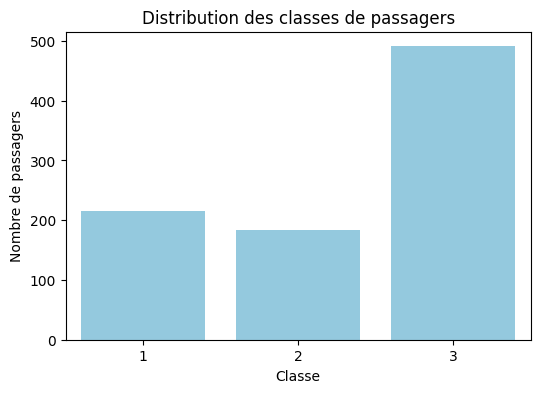

In [73]:
plt.figure(figsize=(6,4))
sns.countplot(x='pclass', data=df, color='skyblue')
plt.title("Distribution des classes de passagers")
plt.xlabel("Classe")
plt.ylabel("Nombre de passagers")
plt.show()

# Questions

### 1. Combien de classes contient le dataset?
### 2. Les classes sont-elles équilibrées?
### 3. Pourquoi cette vérification est-elle indispensable avant toute phase de modélisation?
### 4. Quelles conséquences un déséquilibre de classes pourrait-il avoir sur un futur classifieur?

# 3) Qualité des données

### 1. Quantifier les valeurs manquantes colonne par colonne.

In [74]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


### 2. Vérifier la présence éventuelle de doublons.

In [75]:
doublons = df.duplicated().sum()
print("\nNombre de doublons :", doublons)


Nombre de doublons : 107


### 3. Identifier les colonnes problématiques et expliciter la nature de chaque problème.

| Colonne         | Problème                            | Nature du problème                               |
| --------------- | ----------------------------------- | ------------------------------------------------ |
| `age`           | valeurs manquantes                  | Certaines entrées n’ont pas d’âge                |
| `deck`          | valeurs manquantes massives         | Beaucoup de passagers n’ont pas de deck attribué |
| `embarked`      | valeurs manquantes ou erreurs       | Peut contenir `NaN` ou codes incorrects          |
| Autres colonnes | potentiels doublons ou incohérences | À vérifier selon dataset complet                 |


### 4. Choisir, justifier et appliquer une stratégie de traitement des données manquantes.

In [76]:
# Imputation age par médiane par groupe 'sex'
df['age'] = df.groupby('sex')['age'].transform(lambda x: x.fillna(x.median()))

# Imputation embarked et embark_town par mode
mode_embarked = df['embarked'].mode()[0]
df['embarked'] = df['embarked'].fillna(mode_embarked)

mode_embark_town = df['embark_town'].mode()[0]
df['embark_town'] = df['embark_town'].fillna(mode_embark_town)

# Suppression de la colonne deck
df = df.drop(columns=['deck'])

df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


### 5. Justifier précisément le traitement retenu.

# Questions

### 1. Quelles colonnes posent problème?
### 2. Pourquoi ces problèmes doivent-ils être traités avant toute analyse sérieuse?
### 3. En quoi le traitement choisi peut-il influencer les conclusions ultérieures?
### 4. Quel risque y aurait-il à ignorer cette étape?

# 4) Manipulation et transformation des données

# Questions

# 5) Analyse descriptive des variables

# Questions


# 6) Comparaison entre classes

# Questions

# 7) Relations entre variables et séparabilité

# Questions

# 8) Sélection raisonnée des variables

# Questions

# 9) Préparation à une future modélisation

# Questions

# 10) Discussion critique dans une perspective de machine learning

# Questions

# 3 Bonus